In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

# 2. Load Dataset
df = pd.read_csv(url)

# Save a copy of the raw statistics for Task 12 comparison later
df_raw = df.copy()

print("Dataset loaded successfully. First 5 rows:")
display(df.head())

Dataset loaded successfully. First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
print("--- Dataset Summary ---")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Dataset Summary ---
Number of rows: 299
Number of columns: 13

--- Data Types ---
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

--- Missing Values ---
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


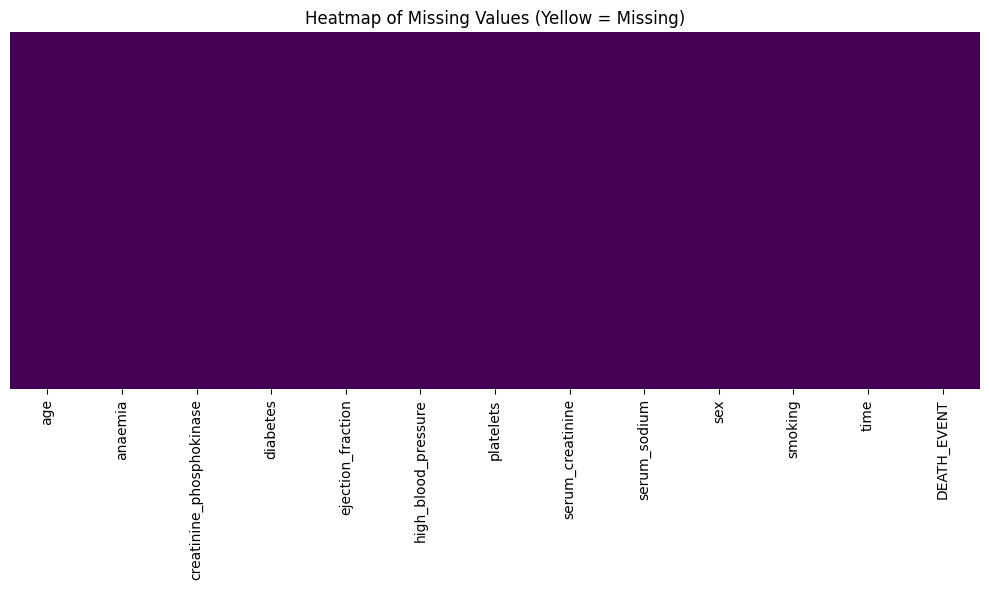

In [ ]:
plt.figure(figsize=(10, 6))
# Using seaborn heatmap to visualize where missing values occur in the dataset
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Heatmap of Missing Values (Yellow = Missing)")
plt.tight_layout()
plt.show()

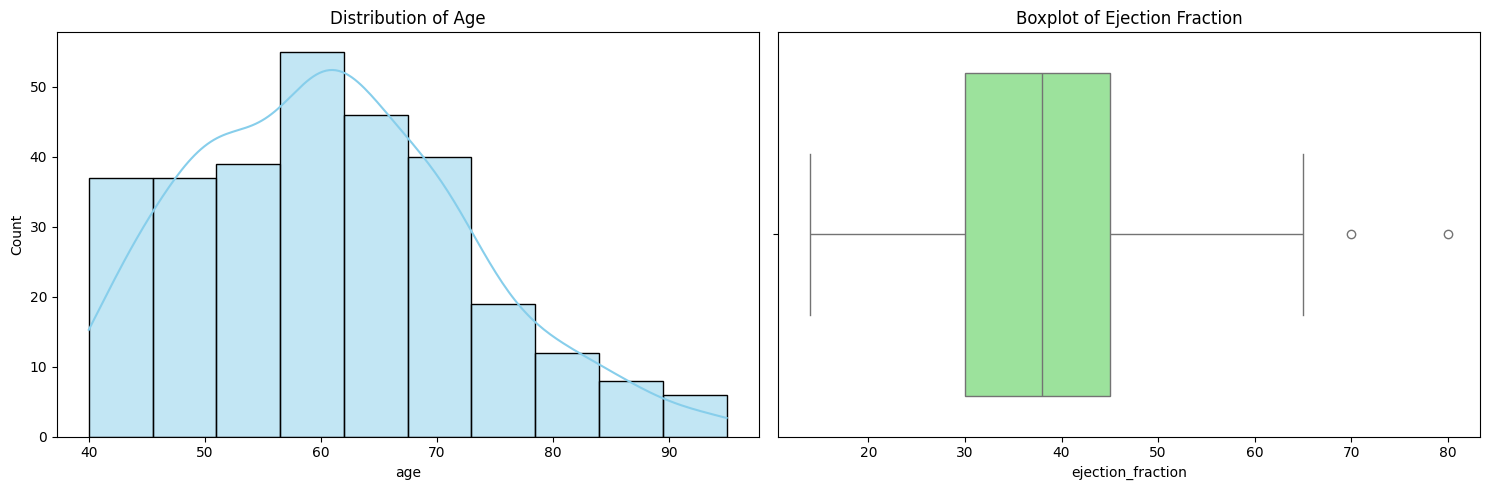

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram for age
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')

# Boxplot for ejection_fraction
sns.boxplot(x=df['ejection_fraction'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Ejection Fraction')

plt.tight_layout()
plt.show()


In [ ]:
print("Missing values before imputation:")
print(df[['serum_creatinine', 'smoking']].isnull().sum())

# 1. Numerical feature (serum_creatinine): Impute using median or mean.
# We'll use median to be robust against outliers.
serum_median = df['serum_creatinine'].median()
df['serum_creatinine'] = df['serum_creatinine'].fillna(serum_median)

# 2. Categorical feature (smoking): Impute using mode or "Unknown".
# We will use the mode (most frequent value).
smoking_mode = df['smoking'].mode()[0]
df['smoking'] = df['smoking'].fillna(smoking_mode)

print("\nMissing values after imputation:")
print(df[['serum_creatinine', 'smoking']].isnull().sum())

Missing values before imputation:
serum_creatinine    0
smoking             0
dtype: int64

Missing values after imputation:
serum_creatinine    0
smoking             0
dtype: int64


In [ ]:
Q1 = df['platelets'].quantile(0.25)
Q3 = df['platelets'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

initial_row_count = df.shape[0]

# Filter out the outliers
df = df[(df['platelets'] >= lower_bound) & (df['platelets'] <= upper_bound)]

final_row_count = df.shape[0]
print(f"Removed {initial_row_count - final_row_count} outliers based on the 'platelets' feature.")


Removed 21 outliers based on the 'platelets' feature.


In [ ]:
# Check for invalid entries (negative ages)
invalid_ages = df[df['age'] < 0]
print(f"Found {len(invalid_ages)} entries with negative age.")

# Fix them by taking the absolute value
# (Alternatively, we could drop them, but correcting is preferred if it's a sign error)
df['age'] = df['age'].abs()

print("Negative age values have been corrected using absolute values.")
print(f"Number of negative ages remaining: {len(df[df['age'] < 0])}")

Found 0 entries with negative age.
Negative age values have been corrected using absolute values.
Number of negative ages remaining: 0


In [ ]:
# 1. Create age_group feature (bins: <40, 40-60, >60)
# We use pandas cut function to bin the numerical age column into categories.
bins = [0, 39.99, 60, np.inf]
labels = ['<40', '40-60', '>60']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# 2. Create risk_score feature
# Normalized product of ejection_fraction and serum_creatinine
product_col = df['ejection_fraction'] * df['serum_creatinine']
# Normalize to 0-1 scale using simple Min-Max math
min_val = product_col.min()
max_val = product_col.max()
df['risk_score'] = (product_col - min_val) / (max_val - min_val)

print("Engineered Features preview:")
display(df[['age', 'age_group', 'ejection_fraction', 'serum_creatinine', 'risk_score']].head())

Engineered Features preview:


,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75.0,>60,20,1.9,0.043310
1,55.0,40-60,38,1.1,0.049451
2,65.0,>60,20,1.3,0.023917
3,50.0,40-60,20,1.9,0.043310
4,65.0,>60,20,2.7,0.069166


In [ ]:
df['sex'] = df['sex'].map({0: 'Female', 1: 'Male'})
df['smoking'] = df['smoking'].map({0.0: 'Non-Smoker', 1.0: 'Smoker'})

# Apply One-Hot Encoding to our categorical variables: age_group, sex, and smoking
# This creates binary columns for each category.
categorical_cols = ['age_group', 'sex', 'smoking']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print("Categorical features encoded successfully. New columns created:")
print([col for col in df.columns if 'age_group' in col or 'sex' in col or 'smoking' in col])

Categorical features encoded successfully. New columns created:
['age_group_<40', 'age_group_40-60', 'age_group_>60', 'sex_Female', 'sex_Male', 'smoking_Non-Smoker', 'smoking_Smoker']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Define numerical features to scale (excluding our encoded and engineered ones for clarity)
features_to_scale = ['age', 'platelets', 'creatinine_phosphokinase', 'serum_sodium']

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Features normalized. Here is the statistical minimum and maximum (should be 0 and 1):")
display(df[features_to_scale].agg(['min', 'max']))

Features normalized. Here is the statistical minimum and maximum (should be 0 and 1):


,age,platelets,creatinine_phosphokinase,serum_sodium
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


In [ ]:
# We calculate mean, median, and std deviation before and after cleaning.
cols_to_compare = ['age', 'platelets', 'serum_creatinine']

print("=== SUMMARY STATISTICS BEFORE CLEANING ===")
# Re-calculating median manually since describe() gives 50% percentile (which is median)
raw_stats = df_raw[cols_to_compare].describe().T[['mean', '50%', 'std']]
raw_stats.rename(columns={'50%': 'median'}, inplace=True)
display(raw_stats)

print("\n=== SUMMARY STATISTICS AFTER CLEANING ===")
cleaned_stats = df[cols_to_compare].describe().T[['mean', '50%', 'std']]
cleaned_stats.rename(columns={'50%': 'median'}, inplace=True)
display(cleaned_stats)

=== SUMMARY STATISTICS BEFORE CLEANING ===


,mean,median,std
age,60.833893,60.0,11.894809
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510



=== SUMMARY STATISTICS AFTER CLEANING ===


,mean,median,std
age,0.374057,0.363636,0.213877
platelets,0.493144,0.502941,0.199938
serum_creatinine,1.390432,1.100000,1.057420


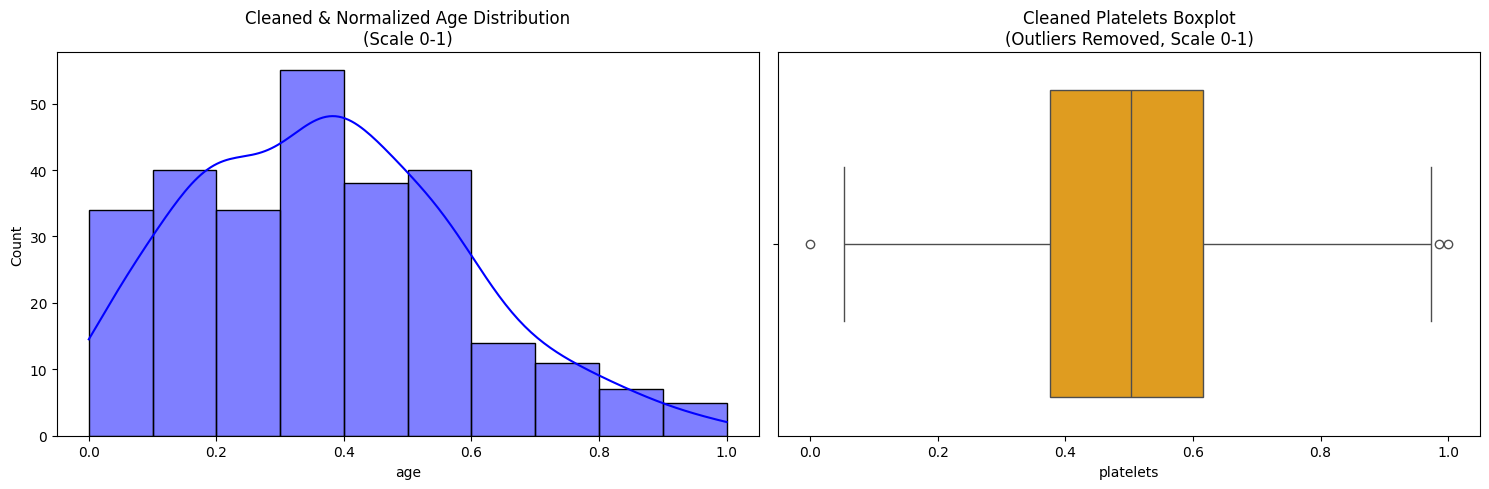

In [ ]:
# Re-plotting histograms and boxplots to visually validate that the data is clean
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plotting the normalized age
sns.histplot(df['age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Cleaned & Normalized Age Distribution\n(Scale 0-1)')

# Plotting platelets to show outliers are gone
sns.boxplot(x=df['platelets'], ax=axes[1], color='orange')
axes[1].set_title('Cleaned Platelets Boxplot\n(Outliers Removed, Scale 0-1)')

plt.tight_layout()
plt.show()

In [ ]:
total_missing = df.isnull().sum().sum()

print("--- Final Missing Values Check ---")
if total_missing == 0:
    print(f"Success: Verified 0 missing values remain in the dataset.")
else:
    print(f"Warning: {total_missing} missing values still remain.")
    print(df.isnull().sum()[df.isnull().sum() > 0])

--- Final Missing Values Check ---
Success: Verified 0 missing values remain in the dataset.
